In [1]:
# ═══════════════════════════════════════════════════════
#  ЗАПУСТИ ОДИН РАЗ при открытии ноутбука
# ═══════════════════════════════════════════════════════
from pathlib import Path
from math import ceil
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from PIL import Image

%matplotlib widget
%matplotlib inline


repo_root = Path.cwd()
if not (repo_root / 'data' / 'final_dataset').exists():
    repo_root = repo_root.parent.parent

IMG_DIR = repo_root / 'data' / 'final_dataset' / 'images'
LBL_DIR = repo_root / 'data' / 'final_dataset' / 'labels'
CLASS_NAMES = [
    'HM','LQS','QHS','MS','A1_SU-35','A2_C-130','A3_C-17','A4_C-5','A5_F-16',
    'A6_TU-160','A7_E-3','A8_B-52','A9_P-3C','A10_B-1B','A11_E-8','A12_TU-22',
    'A13_F-15','A14_KC-135','A15_F-22','A16_FA-18','A17_TU-95','A18_KC-10',
    'A19_SU-34','A20_SU-24','FSC',
]
COLORS = plt.colormaps['tab20'].resampled(len(CLASS_NAMES))
FLAGGED_FILE = repo_root / 'runs' / 'label_review' / 'flagged_MS.txt'
FLAGGED_FILE.parent.mkdir(parents=True, exist_ok=True)

TARGET_CLASS = 'MS'
target_id = CLASS_NAMES.index(TARGET_CLASS)

def read_yolo(lbl_path):
    boxes = []
    for ln, line in enumerate(lbl_path.read_text().splitlines(), 1):
        parts = line.split()
        if len(parts) == 5:
            boxes.append((ln, int(parts[0]), *map(float, parts[1:])))
    return boxes

# Строим список всех изображений с классом MS, 1 раз
candidates = []
for lbl in sorted(LBL_DIR.glob('*.txt')):
    if any(int(l.split()[0]) == target_id for l in lbl.read_text().splitlines() if l.split()):
        img = IMG_DIR / (lbl.stem + '.jpg')
        if not img.exists():
            img = IMG_DIR / (lbl.stem + '.png')
        if img.exists():
            candidates.append((img, lbl))

print(f'Изображений с классом "{TARGET_CLASS}": {len(candidates)}')
print(f'Нумерация: 1 – {len(candidates)}')

Изображений с классом "MS": 1942
Нумерация: 1 – 1942


Страница 5 | #9 – #10  (всего 1942)


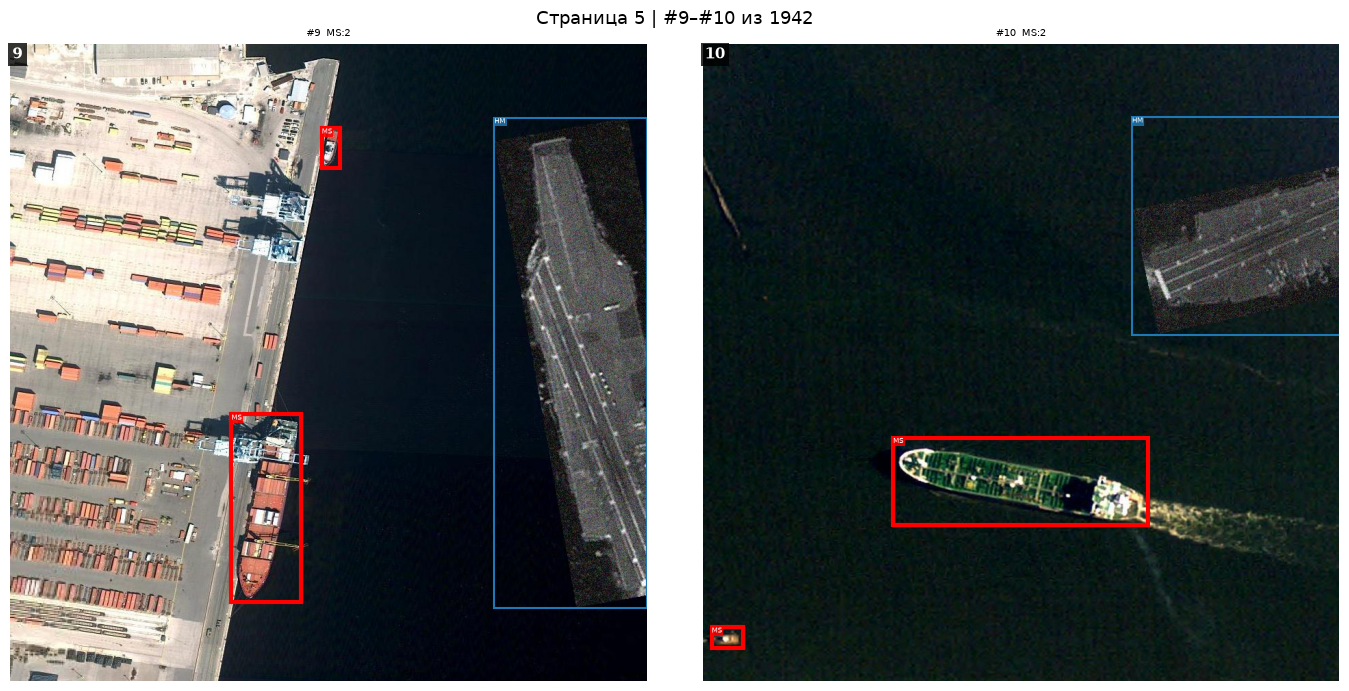

In [2]:
# ═══════════════════════════════════════════════════════
#  Меняй только PAGE и запускай (Shift+Enter)
#  PAGE=1 → #1–50,  PAGE=2 → #51–100,  PAGE=3 → #101–150 ...
# ═══════════════════════════════════════════════════════
PAGE = 5   # ← МЕНЯЙ

BATCH_SIZE = 2
COLS       = 2

plt.close('all')
_start = (PAGE - 1) * BATCH_SIZE
_end   = min(_start + BATCH_SIZE, len(candidates))
_batch = list(range(_start, _end))
print(f'Страница {PAGE} | #{_start + 1} – #{_end}  (всего {len(candidates)})')

_rows = ceil(len(_batch) / COLS)
fig, axes = plt.subplots(_rows, COLS, figsize=(COLS * 7, _rows * 7))
axes = list(np.array(axes).flat)

for ax, idx in zip(axes, _batch):
    img_path, lbl_path = candidates[idx]
    num = idx + 1
    img = Image.open(img_path).convert('RGB')
    W, H = img.size
    ax.imshow(img)
    boxes = read_yolo(lbl_path)
    for ln, cls, cx, cy, bw, bh in boxes:
        x1, y1 = (cx - bw/2)*W, (cy - bh/2)*H
        is_ms  = (cls == target_id)
        color  = 'red' if is_ms else COLORS(cls)
        ax.add_patch(Rectangle((x1, y1), bw*W, bh*H,
                                fill=False, edgecolor=color,
                                linewidth=3 if is_ms else 1.5))
        ax.text(max(0, x1), max(0, y1), CLASS_NAMES[cls], color='white',
                fontsize=5, va='top',
                bbox=dict(facecolor=color, alpha=0.85, pad=1, edgecolor='none'))
    ax.text(3, 3, f'{num}', color='white', fontsize=11, fontweight='bold', va='top',
            bbox=dict(facecolor='black', alpha=0.8, pad=3, edgecolor='none'))
    ms_cnt = sum(1 for b in boxes if b[1] == target_id)
    ax.set_title(f'#{num}  MS:{ms_cnt}', fontsize=7)
    ax.axis('off')

for ax in axes[len(_batch):]:
    ax.axis('off')
plt.suptitle(f'Страница {PAGE} | #{_start+1}–#{_end} из {len(candidates)}', fontsize=13)
plt.tight_layout()
plt.show()

In [3]:
# ═══════════════════════════════════════════════════════
#  ФЛАГИ: пиши номера изображений которые нужно проверить
#  Список накапливается, можно запускать много раз
# ═══════════════════════════════════════════════════════
new_flags = [
    1,
    10, 
    17,
    28, 
    29, 
    45, 
    50,
    54,
    71,
    74,
    76,
    95,
    100,
    104,
    115,
    139,
    153,
    208,
    214,
    223,
    224,
    225,
    227,
    230,
    231,
    232,
    233,
    236,
    250,
    251,
    259,
    292,
    306,
    315,
    328,
    347,
    352,
    372,
    393,
    397,
    398,
    399,
    400,
    403,
    413,
    414,
    415,
    417,
    420,
    421,
    423,
    437,
    462,
    473,
    475,
    495,
    499,
    505,
    513,
    515,
    527,
    528,
    529,
    530,
    535,
    536,
    543,
    546,
    547,
    557,
    560,
    579,
    599,
    600,
    601,
    606,
    610,
    611,
    615,
    619,
    620,
    621,
    622,
    623,
    624,
    626,
    627,
    630,
    631,
    632,
    633,
    634, 
    635, 
    636, 
    637,
    640,
    641, 
    642, 
    644,
    645,
    647,
    649,
    652,
    653,
    661,
    662,
    667,
    677,
    694,
    699,
    700,
    709,
    720,
    723,
    725,
    728,
    732,
    734,
    737,
    746,
    749,
    751,
    752,
    755,
    756,
    758,
    759,
    761,
    762,
    765,
    768,
    778,
    779,
    782,
    785,
    787,
    792,
    795,
    796,
    799,
    801,
    804,
    811,
    812,
    818,
    820,
    824,
    826,
    843,
    844,
    847,
    849,
    850,
    851,
    854,
    856,
    870,
    875,
    877,
    884,
    885,
    886,
    892,
    895,
    896,
    898,
    899,
    902,
    908,
    913,
    920,
    921,
    939,
    944,
    945,
    948,
    950,
    964,
    967,
    985,
    993,
    998,
    1000,
    1002,
    1009,
    1015,
    1022,
    1024,
    1025,
    1029,
    1030,
    1036,
    1056,
    1059,
    1061,
    1062,
    1065,
    1066,
    1067,
    1075,
    1078,
    1089,
    1093,
    1094,
    1095,
    1113,
    1157,
    1167,
    1172,
    1244,
    1370,
    1382,
    1394,
    1398,
    1401,
    1404,
    1448,
    1487,
    1528,
    1529,
    1533,
    1534,
    1535,
    1555,
    1572,
    1634,
    1642,
    1705,
    1715,
    1716,
    1718,
    1723,
    1724,
    1728,
    1732,
    1734,
    1736,
    1738,
    1740,
    1742,
    1754,
    1757,
    1760,
    1761,
    1764,
    1766,
    1768,
    1775,
    1777,
    1779,
    1786,
    1788,
    1789,
    1794,
    1807,
    1819,
    1823,
    1856,
    1858,
    1871,
    1872,
    1873,
    1874,
    1877,
    1878,
    1880,
    1893,
    1895,
    1896,
    1898,
    1900,
    1913,
    1919,
    1920,
    1927,
    1929,
    1941,
    1942,
    1947,
    1948,
    1949,
    1950,
    1953,
    1954,
    1955
]

# Загружаем уже сохранённые
saved = set()
if FLAGGED_FILE.exists():
    saved = {l.strip() for l in FLAGGED_FILE.read_text().splitlines() if l.strip()}

# Добавляем новые
for n in new_flags:
    idx = n - 1
    if 0 <= idx < len(candidates):
        stem = candidates[idx][0].stem
        saved.add(stem)
        print(f'  ✓ {n} → {stem}')
    else:
        print(f'  ✗ {n} — нет такого номера')

FLAGGED_FILE.write_text('\n'.join(sorted(saved)))
print(f'\nВсего помечено: {len(saved)}')

  ✓ 1 → 000161_bmp.rf.6766bf8a799d1b8bf76108665e481c5e
  ✓ 10 → 000244_bmp.rf.0a8ce50306151d327b58e3e85e941133
  ✓ 17 → 000280_bmp.rf.af27d7bf52d70292f9577a7c3c8f65df
  ✓ 28 → 000363_bmp.rf.aa9e11ce45e9cc1e77b05e44b8a09a99
  ✓ 29 → 000384_bmp.rf.aed6fd70067ef48177ba08ce52e2de32
  ✓ 45 → 000456_bmp.rf.3d0ebe3fe75b107ae0a69a094936be29
  ✓ 50 → 000509_bmp.rf.3233e2cb244a78c43138fe03a898c4ab
  ✓ 54 → 000536_bmp.rf.835142585da875ba33d23ad1753dcc62
  ✓ 71 → 000837_bmp.rf.c258a0ed7c5f4c1a08c090f158e2776c
  ✓ 74 → 000865_bmp.rf.f49216ffce49053d4d8158cadf55e2d3
  ✓ 76 → 000915_bmp.rf.ad87bc554fbbbd02ecfe14d2ecbff066
  ✓ 95 → 001576_bmp.rf.b312e2dab23c3c0870461aba9909309a
  ✓ 100 → 001865_bmp.rf.6822e0f917032bc7e4bcfbc8fe7ebdff
  ✓ 104 → 002330_bmp.rf.511574d5ba3b6bdf8d923cf5c6c70c4b
  ✓ 115 → 002789_bmp.rf.493b1938d59a136cb93d76c33f2a0bd4
  ✓ 139 → 003413_bmp.rf.7a67977434753bedca0af09333bb2aa0
  ✓ 153 → 003986_bmp.rf.4929bd258d86e7486ca821f88e9cce9b
  ✓ 208 → 004601_bmp.rf.f91b1332aea113b31920

# ═══════════════════════════════════════════════════════
#  ПРОСМОТР всех помеченных
# ═══════════════════════════════════════════════════════
stems = [l.strip() for l in FLAGGED_FILE.read_text().splitlines() if l.strip()] if FLAGGED_FILE.exists() else []
stem_to_idx = {candidates[i][0].stem: i+1 for i in range(len(candidates))}

if not stems:
    print('Нет помеченных изображений.')
else:
    COLS_F = 2
    rows_f = ceil(len(stems) / COLS_F)
    fig, axes = plt.subplots(rows_f, COLS_F, figsize=(14, rows_f * 7))
    axes = list(np.array(axes).flat)

    for ax, stem in zip(axes, stems):
        ip = IMG_DIR / (stem + '.jpg')
        if not ip.exists(): ip = IMG_DIR / (stem + '.png')
        lp = LBL_DIR / (stem + '.txt')
        num = stem_to_idx.get(stem, '?')
        if ip.exists():
            img = Image.open(ip).convert('RGB')
            W, H = img.size
            ax.imshow(img)
            for ln, cls, cx, cy, bw, bh in read_yolo(lp):
                x1, y1 = (cx - bw/2)*W, (cy - bh/2)*H
                is_ms = (cls == target_id)
                color = 'red' if is_ms else COLORS(cls)
                ax.add_patch(Rectangle((x1, y1), bw*W, bh*H, fill=False,
                                       edgecolor=color, linewidth=2.5 if is_ms else 1.2))
            ax.text(6, 6, f'{num}', color='white', fontsize=20, fontweight='bold', va='top',
                    bbox=dict(facecolor='black', alpha=0.8, pad=5, edgecolor='none'))
            ax.set_title(f'{num} — {stem}', fontsize=7)
        else:
            ax.set_title(f'{num} — не найден', fontsize=8)
        ax.axis('off')

    for ax in axes[len(stems):]:
        ax.axis('off')
    plt.suptitle(f'Помечено: {len(stems)} изображений', fontsize=12)
    plt.tight_layout()
    plt.show()

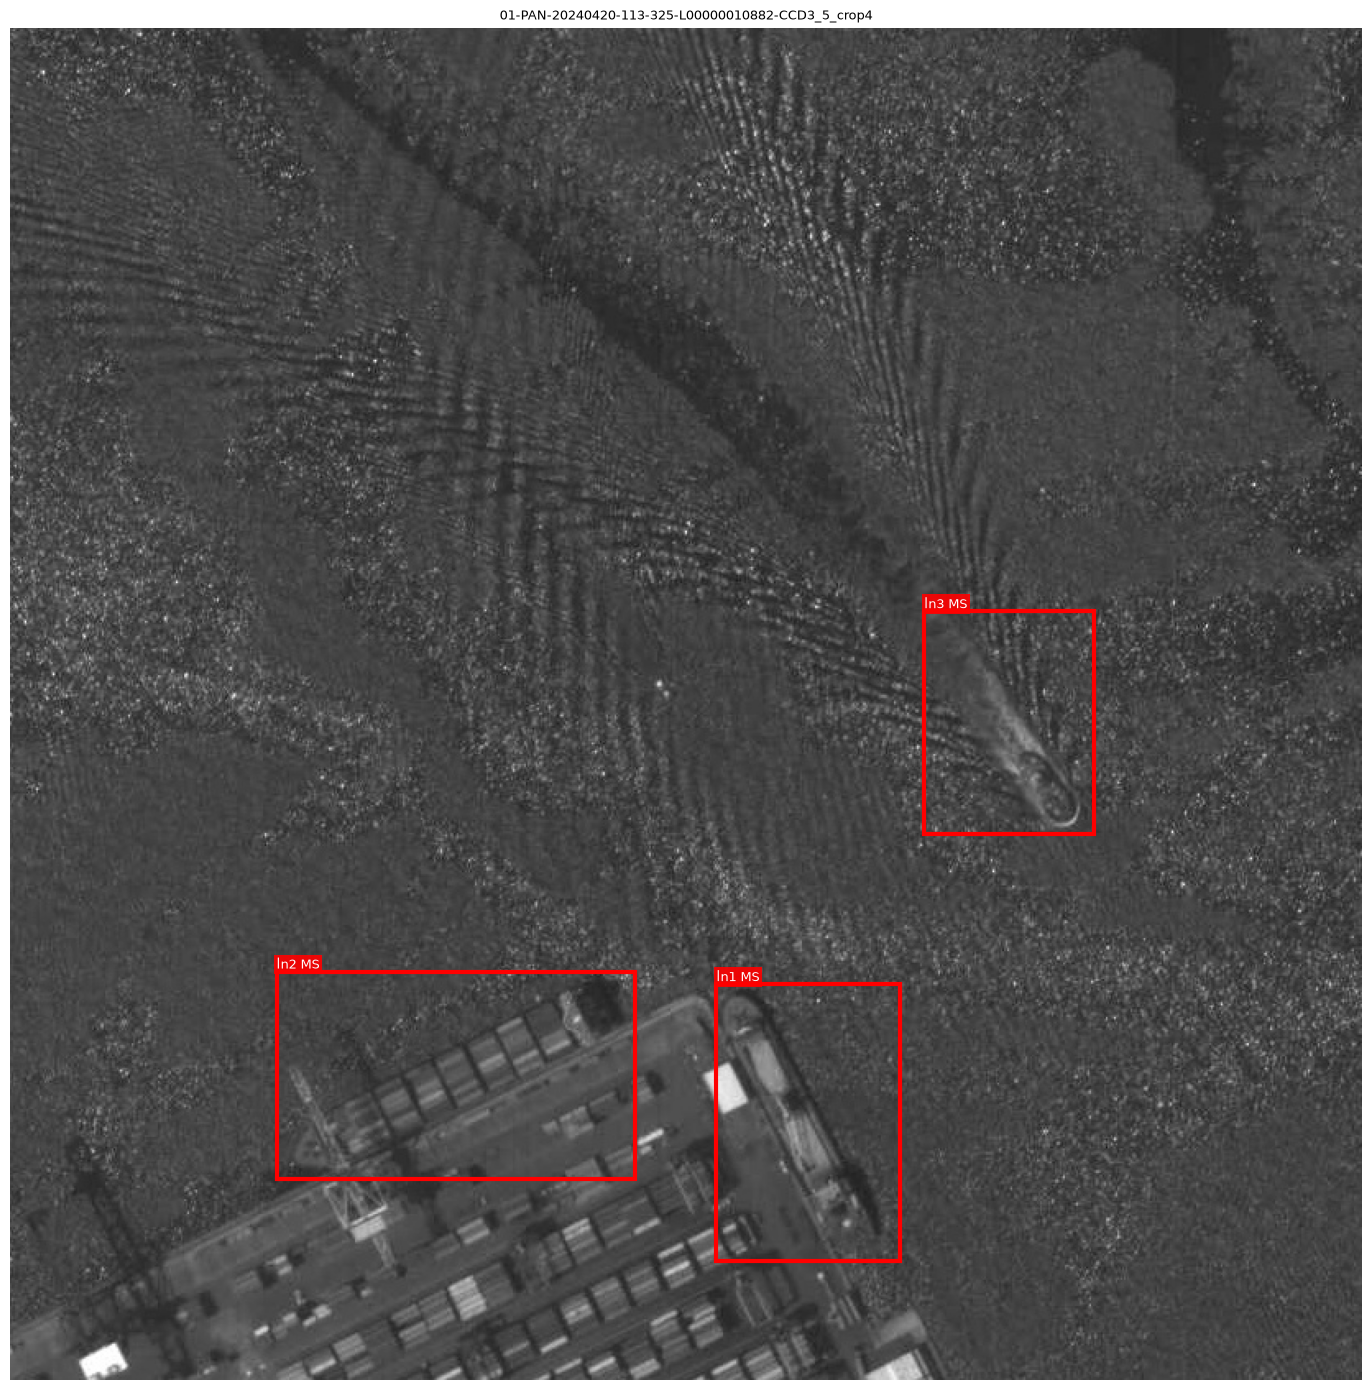


Файл: /home/irdorat/ML_comp/data/final_dataset/labels/01-PAN-20240420-113-325-L00000010882-CCD3_5_crop4.txt
ln    cls   name                  cx       cy        w        h
------------------------------------------------------------
1     3     MS                0.5896   0.8091   0.1356   0.2049  ◄ MS
2     3     MS                0.3290   0.7741   0.2649   0.1535  ◄ MS
3     3     MS                0.7382   0.5132   0.1252   0.1649  ◄ MS


In [38]:
%matplotlib inline

IMAGE_NAME = '01-PAN-20240420-113-325-L00000010882-CCD3_5_crop4'

plt.close('all')
img_path = IMG_DIR / (IMAGE_NAME + '.jpg')
if not img_path.exists():
    img_path = IMG_DIR / (IMAGE_NAME + '.png')
lbl_path = LBL_DIR / (IMAGE_NAME + '.txt')

img = Image.open(img_path).convert('RGB')
W, H = img.size

fig, ax = plt.subplots(figsize=(14, 14))
ax.imshow(img)

boxes = read_yolo(lbl_path)
for ln, cls, cx, cy, bw, bh in boxes:
    x1, y1 = (cx - bw/2)*W, (cy - bh/2)*H
    is_ms  = (cls == target_id)
    color  = 'red' if is_ms else COLORS(cls)
    ax.add_patch(Rectangle((x1, y1), bw*W, bh*H,
                            fill=False, edgecolor=color,
                            linewidth=3 if is_ms else 2))
    ax.text(x1, y1, f'ln{ln} {CLASS_NAMES[cls]}', color='white',
            fontsize=9, va='bottom',
            bbox=dict(facecolor=color, alpha=0.9, pad=2, edgecolor='none'))

ax.set_title(IMAGE_NAME, fontsize=9)
ax.axis('off')
plt.tight_layout()
display(fig)
plt.close(fig)

print(f'\nФайл: {lbl_path}')
print(f'{"ln":<4}  {"cls":<4}  {"name":<15}  {"cx":>7}  {"cy":>7}  {"w":>7}  {"h":>7}')
print('-' * 60)
for ln, cls, cx, cy, bw, bh in boxes:
    mark = '  ◄ MS' if cls == target_id else ''
    print(f'{ln:<4}  {cls:<4}  {CLASS_NAMES[cls]:<15}  {cx:>7.4f}  {cy:>7.4f}  {bw:>7.4f}  {bh:>7.4f}{mark}')


In [ ]:
labelImg

IsADirectoryError: [Errno 21] Is a directory: '/'